<a href="https://colab.research.google.com/github/diyasicilysiju/drone/blob/main/drone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import random

# Set reproducibility
np.random.seed(42)

N = 1000  # number of records

# --- A. Drone Signature Features ---
RCS = np.random.uniform(0.01, 10, N)
Thermal_IR = np.random.uniform(0, 100, N)
RF_power = np.random.uniform(0, 50, N)
Metallic_index = np.random.uniform(0, 1, N)

# --- B. Flight Data ---
Altitude = np.random.uniform(0, 2000, N)
Speed = np.random.uniform(0, 200, N)
Acceleration = np.random.uniform(-10, 20, N)
Turn_rate = np.random.uniform(0, 180, N)

# --- C. Payload Indicators ---
Payload_weight = np.random.uniform(0, 50, N)
Heatmap_anomaly = np.random.uniform(0, 1, N)
Payload_metallic_index = np.random.uniform(0, 1, N)

# --- D. Environment Data ---
Weather = np.random.choice(["Clear", "Rain", "Fog", "Windy"], N)
Wind_speed = np.random.uniform(0, 30, N)
GPS_zone = np.random.choice(["Civilian", "Military"], N)
Visibility = np.random.uniform(0, 10, N)

# --- E. Direct Countermeasure Heuristic (no threat variable) ---
def recommend_countermeasure(rcs, speed, payload, thermal, weather, visibility, zone):
    # --- Critical engagement conditions ---
    if (payload > 35 and speed > 150 and thermal > 70) or (rcs > 8 and zone == "Military"):
        return "Intercept"

    # --- DEW effective in clear conditions with high energy signature ---
    elif (thermal > 60 or rcs > 5) and weather == "Clear" and visibility > 6:
        return "DEW"

    # --- Jamming for high-speed or payload drones in poor visibility/weather ---
    elif (speed > 100 or payload > 20) and weather in ["Rain", "Fog", "Windy"]:
        return "Jam"

    # --- Monitoring for low-activity drones ---
    else:
        return "Monitor"

Recommended_countermeasure = [
    recommend_countermeasure(RCS[i], Speed[i], Payload_weight[i],
                             Thermal_IR[i], Weather[i], Visibility[i], GPS_zone[i])
    for i in range(N)
]

# --- Combine into DataFrame ---
df = pd.DataFrame({
    "RCS": RCS,
    "Thermal_IR": Thermal_IR,
    "RF_power": RF_power,
    "Metallic_index": Metallic_index,
    "Altitude": Altitude,
    "Speed": Speed,
    "Acceleration": Acceleration,
    "Turn_rate": Turn_rate,
    "Payload_weight": Payload_weight,
    "Heatmap_anomaly": Heatmap_anomaly,
    "Payload_metallic_index": Payload_metallic_index,
    "Weather": Weather,
    "Wind_speed": Wind_speed,
    "GPS_zone": GPS_zone,
    "Visibility": Visibility,
    "Recommended_countermeasure": Recommended_countermeasure
})

# --- Save CSV ---
df.to_csv("simulated_drone_dataset.csv", index=False)

print("✅ Dataset generated successfully: simulated_drone_dataset.csv")
df.head()

✅ Dataset generated successfully: simulated_drone_dataset.csv


,RCS,Thermal_IR,RF_power,Metallic_index,Altitude,Speed,Acceleration,Turn_rate,Payload_weight,Heatmap_anomaly,Payload_metallic_index,Weather,Wind_speed,GPS_zone,Visibility,Recommended_countermeasure
0,3.751656,18.513293,13.085284,0.672703,1143.991757,78.727104,9.447709,6.983902,36.013396,0.913578,0.373641,Fog,9.250652,Civilian,9.743176,Jam
1,9.507636,54.190095,12.348940,0.796681,1610.864659,94.687132,-4.828409,33.619055,34.364150,0.525360,0.332912,Clear,26.534896,Military,0.171730,Intercept
2,7.322619,87.294584,45.312729,0.250468,1520.321860,170.909479,16.171837,149.624245,4.787710,0.724910,0.176154,Windy,20.287012,Civilian,9.476517,Jam
3,5.990598,73.222489,12.477310,0.624874,307.799809,68.000877,8.393487,138.018304,46.128620,0.436048,0.607267,Clear,10.227492,Military,3.686774,Monitor
4,1.568626,80.656115,13.597486,0.571746,298.498939,173.929937,-5.283883,63.115684,28.423610,0.630035,0.476624,Rain,16.306031,Military,0.100904,Jam


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.to_csv("/content/drive/MyDrive/simulated_drone_dataset.csv", index=False)

In [ ]:
from google.colab import files
files.download("simulated_drone_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np

# Load your dataset (already uploaded in Colab or Drive)
df = pd.read_csv("simulated_drone_dataset.csv")   # adjust path if needed

# Select numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

# --- Compute required statistics ---
mean_vals = numeric_df.mean()
median_vals = numeric_df.median()
mode_vals = numeric_df.mode().iloc[0]   # first mode row
range_vals = numeric_df.max() - numeric_df.min()
quartiles = numeric_df.quantile([0.25, 0.5, 0.75])
iqr_vals = quartiles.loc[0.75] - quartiles.loc[0.25]
variance_vals = numeric_df.var()
std_dev_vals = numeric_df.std()

# Combine into summary DataFrame
summary_stats = pd.DataFrame({
    "Mean": mean_vals,
    "Median": median_vals,
    "Mode": mode_vals,
    "Range": range_vals,
    "Variance": variance_vals,
    "Std Dev": std_dev_vals,
    "Q1 (25%)": quartiles.loc[0.25],
    "Q2 (50%)": quartiles.loc[0.5],
    "Q3 (75%)": quartiles.loc[0.75],
    "IQR": iqr_vals
})

print("📊 Summary Statistics:")
display(summary_stats)

# Covariance matrix
print("\n📊 Covariance Matrix:")
display(numeric_df.cov())

# Pearson correlation matrix
print("\n📊 Pearson Correlation Matrix:")
display(numeric_df.corr(method="pearson"))

📊 Summary Statistics:


,Mean,Median,Mode,Range,Variance,Std Dev,Q1 (25%),Q2 (50%),Q3 (75%),IQR
RCS,4.907663,4.973106,0.056274,9.940906,8.517364,2.918452,2.367373,4.973106,7.445753,5.078380
Thermal_IR,50.701731,51.873391,0.321826,99.619546,853.749338,29.218989,24.107427,51.873391,76.046506,51.939079
RF_power,25.120286,25.030696,0.000582,49.890461,211.228720,14.533710,13.067549,25.030696,37.955176,24.887628
Metallic_index,0.490375,0.484279,0.000653,0.998904,0.082076,0.286489,0.241901,0.484279,0.737541,0.495640
Altitude,988.210645,989.196194,0.061438,1995.437340,329039.774344,573.619887,489.948011,989.196194,1479.986904,990.038893
Speed,99.692898,98.080563,1.236765,198.633296,3345.345446,57.838961,49.876001,98.080563,147.970356,98.094355
Acceleration,4.799265,4.539291,-9.957150,29.940970,75.551024,8.692009,-2.793350,4.539291,12.693930,15.487281
Turn_rate,86.826711,87.118326,0.043381,179.759465,2630.109343,51.284592,42.478073,87.118326,128.603925,86.125852
Payload_weight,24.324835,23.935048,0.012147,49.788492,199.140818,14.111726,12.469186,23.935048,35.795249,23.326063
Heatmap_anomaly,0.496795,0.495187,0.000053,0.999452,0.079610,0.282153,0.264144,0.495187,0.736217,0.472073



📊 Covariance Matrix:


,RCS,Thermal_IR,RF_power,Metallic_index,Altitude,Speed,Acceleration,Turn_rate,Payload_weight,Heatmap_anomaly,Payload_metallic_index,Wind_speed,Visibility
RCS,8.517364,2.499357,0.615783,-0.024601,58.232189,-10.033542,0.691735,-3.815320,-1.683198,0.049985,-0.004842,0.539979,-0.146674
Thermal_IR,2.499357,853.749338,11.577242,-0.048472,551.604071,50.690155,10.749846,74.864258,1.351935,-0.539958,0.074328,-1.943635,1.899567
RF_power,0.615783,11.577242,211.228720,-0.056460,-73.848248,-17.108889,-3.574896,-34.864233,-1.072070,0.053797,0.319759,-5.795050,-0.250318
Metallic_index,-0.024601,-0.048472,-0.056460,0.082076,-7.364243,0.662136,-0.042663,-0.335703,0.102678,0.000363,0.003544,0.119131,-0.014152
Altitude,58.232189,551.604071,-73.848248,-7.364243,329039.774344,-1853.436685,102.265037,-261.501167,229.310770,0.829111,-9.392743,-114.827787,-8.369033
Speed,-10.033542,50.690155,-17.108889,0.662136,-1853.436685,3345.345446,4.013521,36.449911,-26.071463,-0.045749,-0.921921,-0.280703,6.640090
Acceleration,0.691735,10.749846,-3.574896,-0.042663,102.265037,4.013521,75.551024,17.008004,0.143392,0.032348,0.214858,2.633054,-0.008884
Turn_rate,-3.815320,74.864258,-34.864233,-0.335703,-261.501167,36.449911,17.008004,2630.109343,-35.684090,-0.127790,-0.762338,7.505547,0.787792
Payload_weight,-1.683198,1.351935,-1.072070,0.102678,229.310770,-26.071463,0.143392,-35.684090,199.140818,0.069510,0.004860,-0.052713,-0.858091
Heatmap_anomaly,0.049985,-0.539958,0.053797,0.000363,0.829111,-0.045749,0.032348,-0.127790,0.069510,0.079610,-0.002926,-0.006575,0.001679



📊 Pearson Correlation Matrix:


,RCS,Thermal_IR,RF_power,Metallic_index,Altitude,Speed,Acceleration,Turn_rate,Payload_weight,Heatmap_anomaly,Payload_metallic_index,Wind_speed,Visibility
RCS,1.000000,0.029310,0.014518,-0.029424,0.034785,-0.059440,0.027269,-0.025491,-0.040870,0.060702,-0.005791,0.020793,-0.017100
Thermal_IR,0.029310,1.000000,0.027262,-0.005791,0.032911,0.029994,0.042327,0.049960,0.003279,-0.065495,0.008880,-0.007476,0.022119
RF_power,0.014518,0.027262,1.000000,-0.013560,-0.008858,-0.020353,-0.028299,-0.046775,-0.005227,0.013119,0.076806,-0.044810,-0.005860
Metallic_index,-0.029424,-0.005791,-0.013560,1.000000,-0.044812,0.039959,-0.017133,-0.022849,0.025397,0.004490,0.043190,0.046732,-0.016807
Altitude,0.034785,0.032911,-0.008858,-0.044812,1.000000,-0.055864,0.020511,-0.008889,0.028328,0.005123,-0.057163,-0.022497,-0.004964
Speed,-0.059440,0.029994,-0.020353,0.039959,-0.055864,1.000000,0.007983,0.012288,-0.031942,-0.002803,-0.055644,-0.000545,0.039061
Acceleration,0.027269,0.042327,-0.028299,-0.017133,0.020511,0.007983,1.000000,0.038155,0.001169,0.013190,0.086294,0.034043,-0.000348
Turn_rate,-0.025491,0.049960,-0.046775,-0.022849,-0.008889,0.012288,0.038155,1.000000,-0.049307,-0.008831,-0.051893,0.016447,0.005226
Payload_weight,-0.040870,0.003279,-0.005227,0.025397,0.028328,-0.031942,0.001169,-0.049307,1.000000,0.017458,0.001202,-0.000420,-0.020689
Heatmap_anomaly,0.060702,-0.065495,0.013119,0.004490,0.005123,-0.002803,0.013190,-0.008831,0.017458,1.000000,-0.036207,-0.002619,0.002025


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

=== Full Statistical Analysis (Quartiles, IQR, Five Number Summary, Outliers) ===

                             Min          Q1  Median (Q2)           Q3  \
RCS                     0.056274    2.367373     4.973106     7.445753   
Thermal_IR              0.321826   24.107427    51.873391    76.046506   
RF_power                0.000582   13.067549    25.030696    37.955176   
Metallic_index          0.000653    0.241901     0.484279     0.737541   
Altitude                0.061438  489.948011   989.196194  1479.986904   
Speed                   1.236765   49.876001    98.080563   147.970356   
Acceleration           -9.957150   -2.793350     4.539291    12.693930   
Turn_rate               0.043381   42.478073    87.118326   128.603925   
Payload_weight          0.012147   12.469186    23.935048    35.795249   
Heatmap_anomaly         0.000053    0.264144   

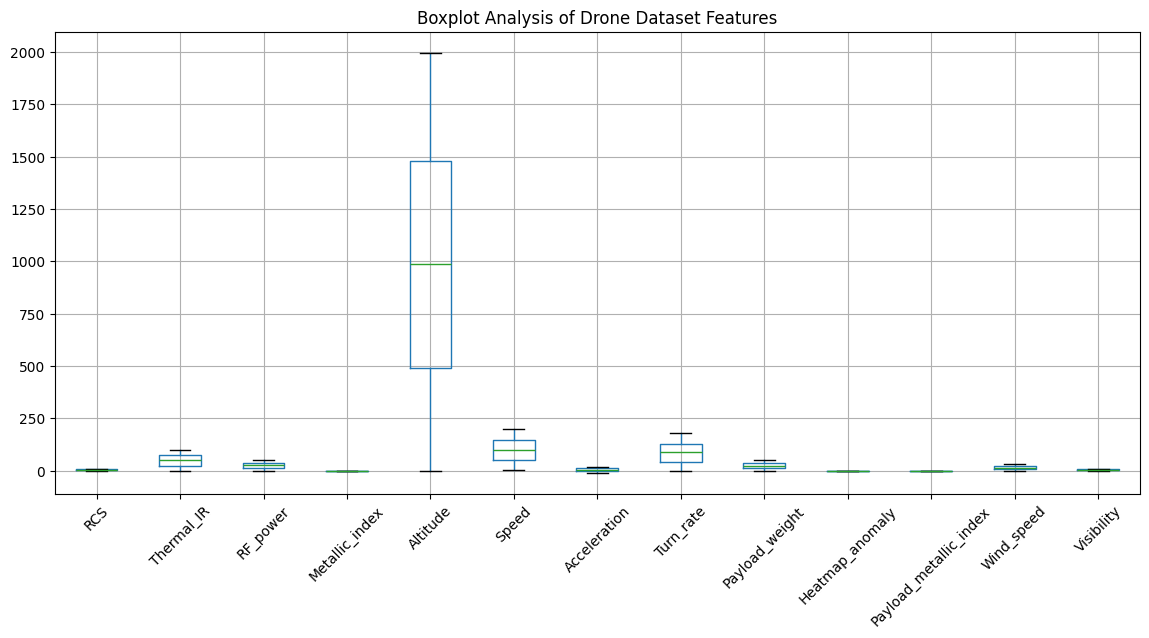

In [ ]:
# --- Full Statistical Analysis Program (Google Drive version) ---

import pandas as pd
import matplotlib.pyplot as plt

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set the path to your file in Drive (adjust path if needed)
file_path = "/content/drive/MyDrive/simulated_drone_dataset.csv"

# Load dataset
df = pd.read_csv(file_path)

# Select only numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns

# Dictionary to store results
analysis_results = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].quantile(0.50)  # Median
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Five Number Summary
    minimum = df[col].min()
    maximum = df[col].max()

    # Outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    analysis_results[col] = {
        "Min": minimum,
        "Q1": Q1,
        "Median (Q2)": Q2,
        "Q3": Q3,
        "Max": maximum,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers Count": len(outliers)
    }

# Convert results to DataFrame
analysis_df = pd.DataFrame(analysis_results).T

# Display results
print("\n=== Full Statistical Analysis (Quartiles, IQR, Five Number Summary, Outliers) ===\n")
print(analysis_df)

# Save results into a CSV file in Drive
output_path = "/content/drive/MyDrive/drone_statistical_analysis.csv"
analysis_df.to_csv(output_path)
print(f"\nResults saved to: {output_path}")

# --- Boxplot visualization ---
plt.figure(figsize=(14, 6))
df[numerical_cols].boxplot(rot=45)
plt.title("Boxplot Analysis of Drone Dataset Features")
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Numeric columns: Index(['RCS', 'Thermal_IR', 'RF_power', 'Metallic_index', 'Altitude', 'Speed',
       'Acceleration', 'Turn_rate', 'Payload_weight', 'Heatmap_anomaly',
       'Payload_metallic_index', 'Wind_speed', 'Visibility'],
      dtype='object')


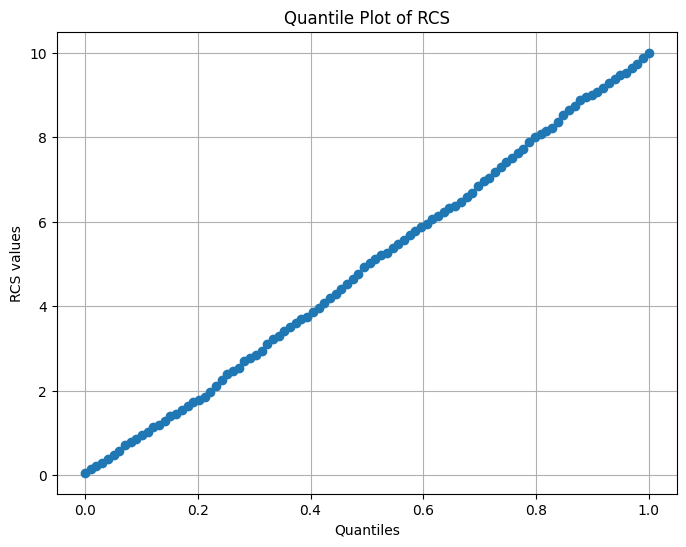

<Figure size 800x600 with 0 Axes>

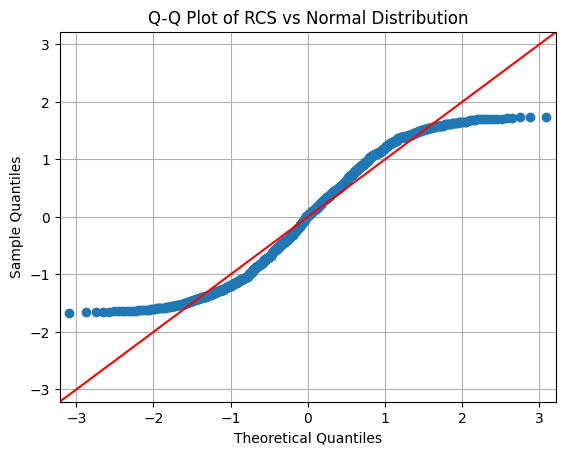

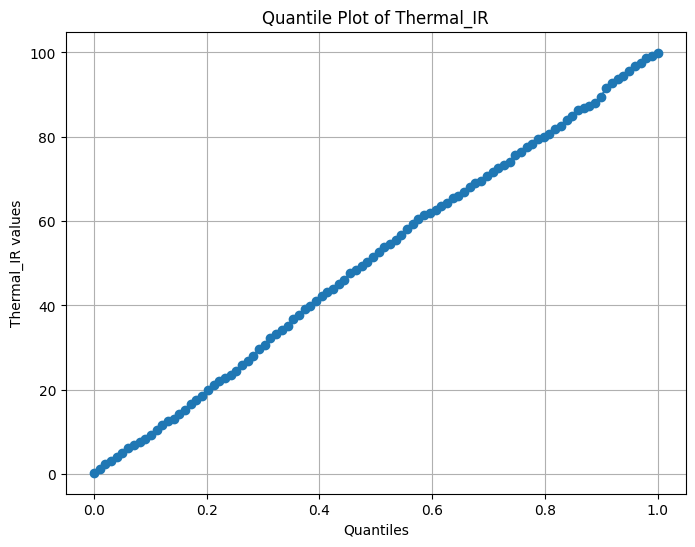

<Figure size 800x600 with 0 Axes>

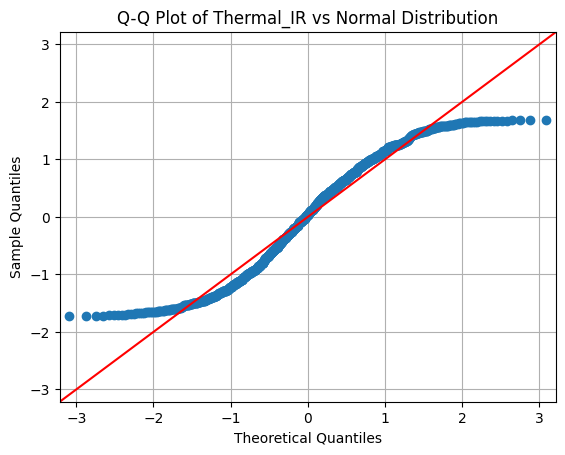

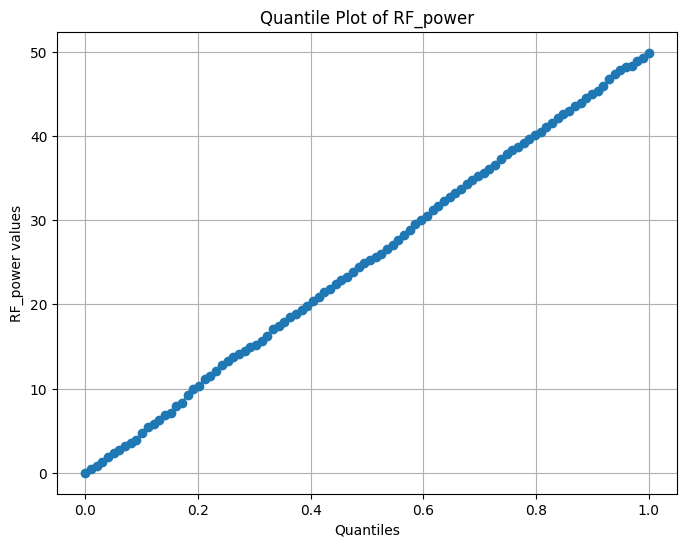

<Figure size 800x600 with 0 Axes>

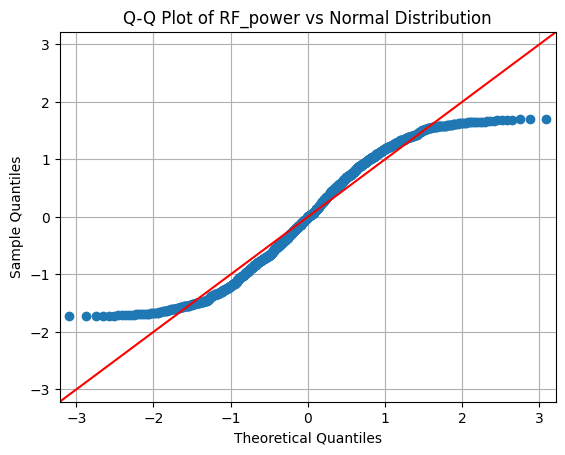

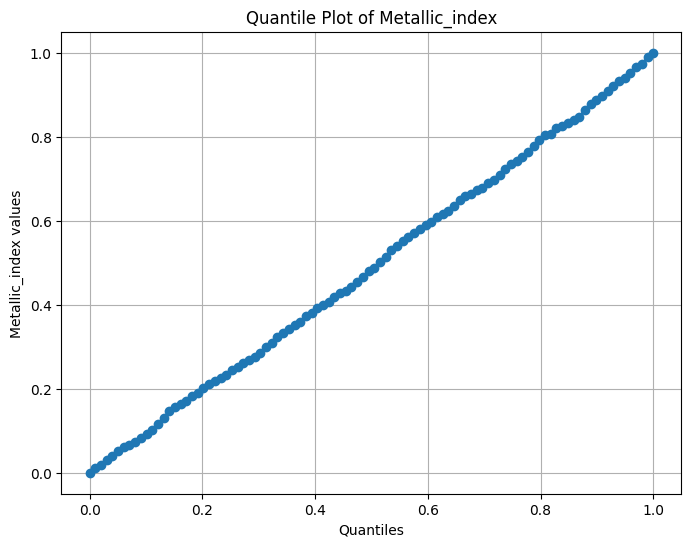

<Figure size 800x600 with 0 Axes>

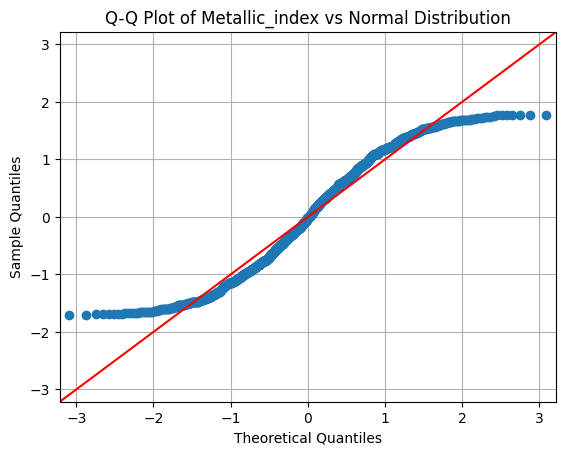

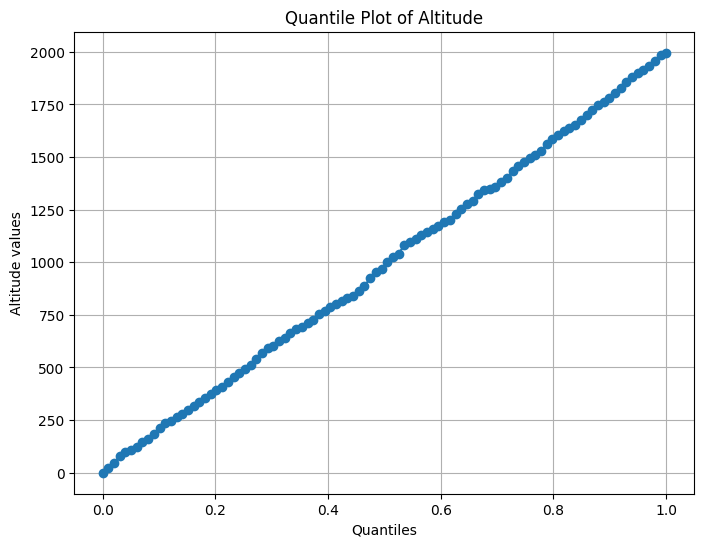

<Figure size 800x600 with 0 Axes>

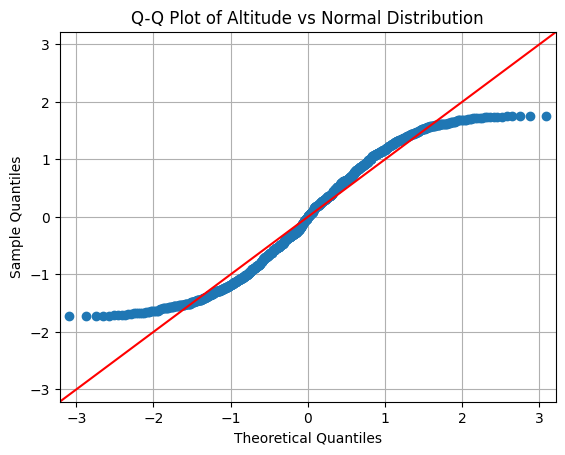

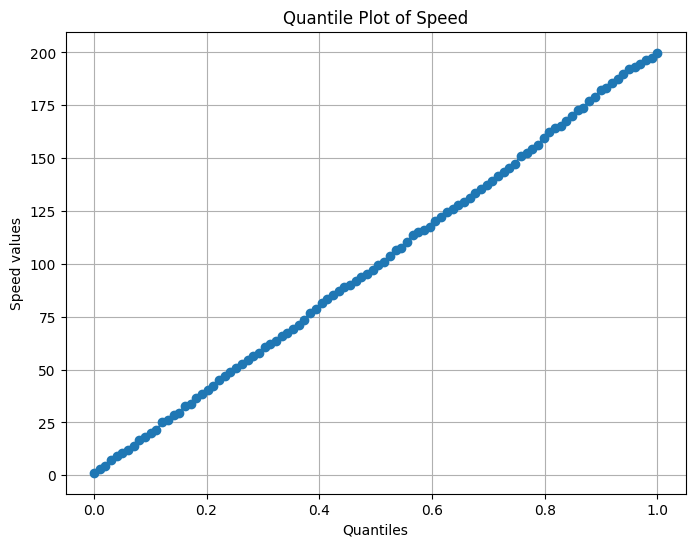

<Figure size 800x600 with 0 Axes>

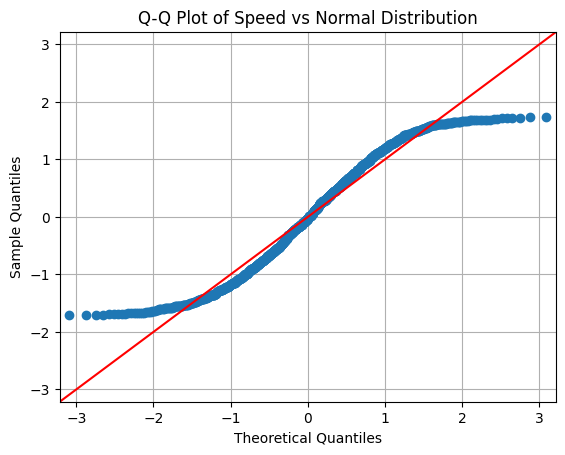

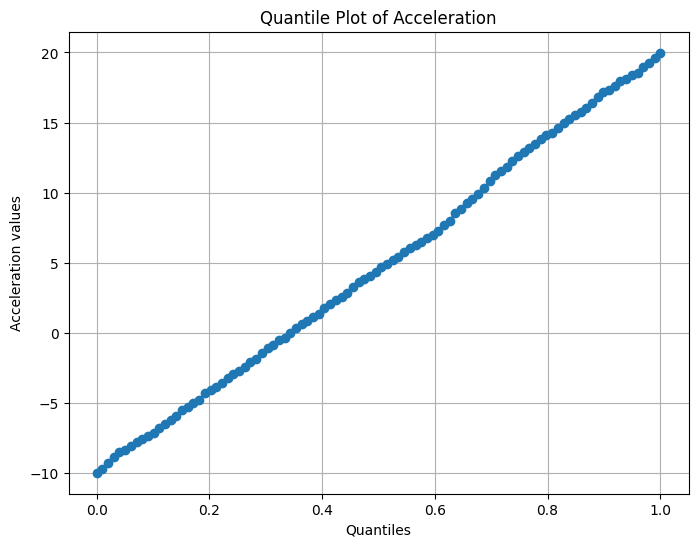

<Figure size 800x600 with 0 Axes>

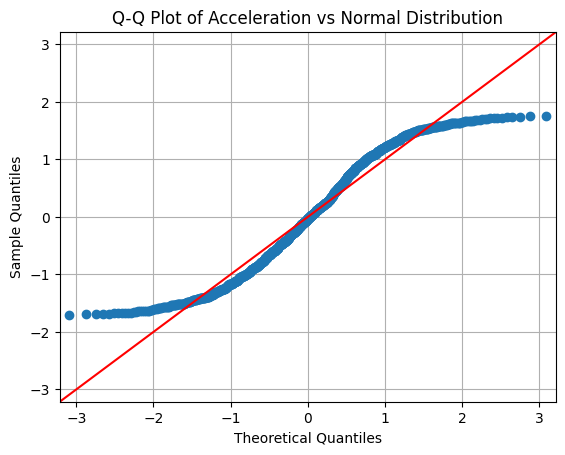

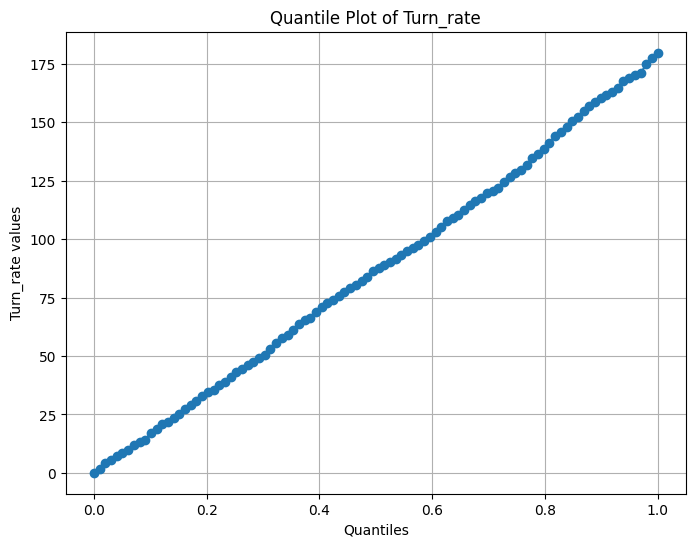

<Figure size 800x600 with 0 Axes>

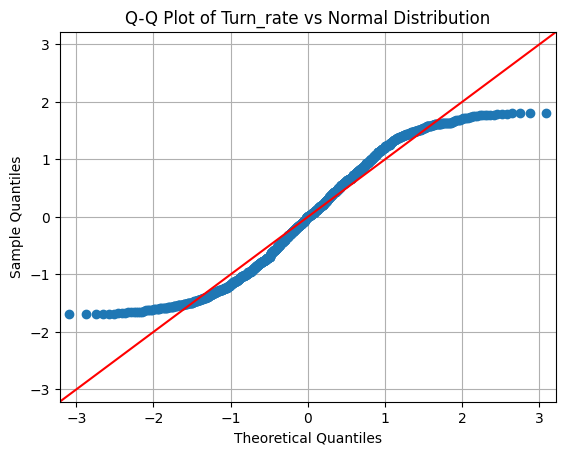

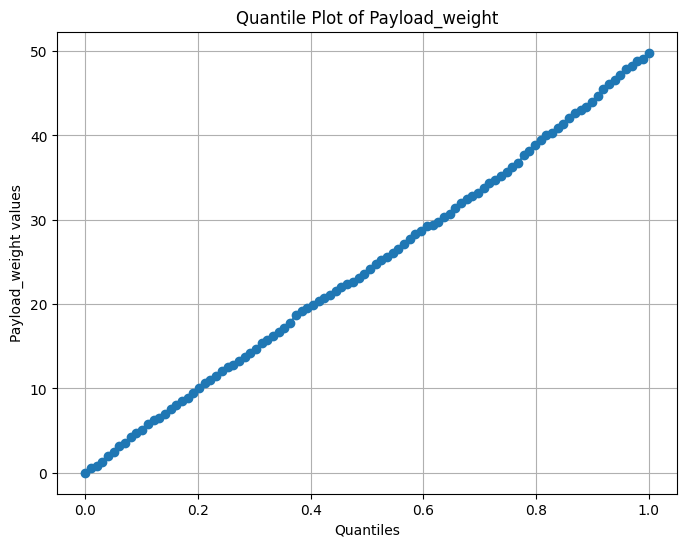

<Figure size 800x600 with 0 Axes>

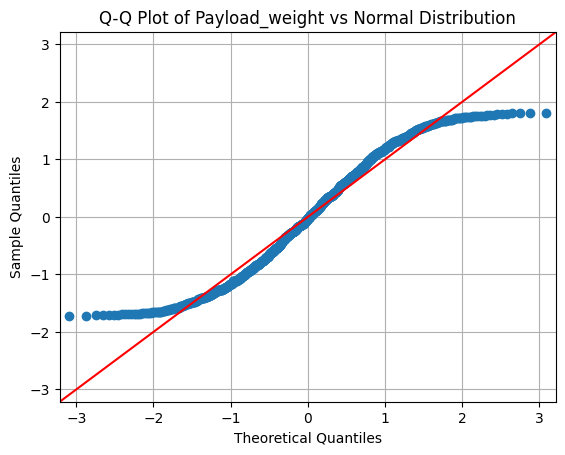

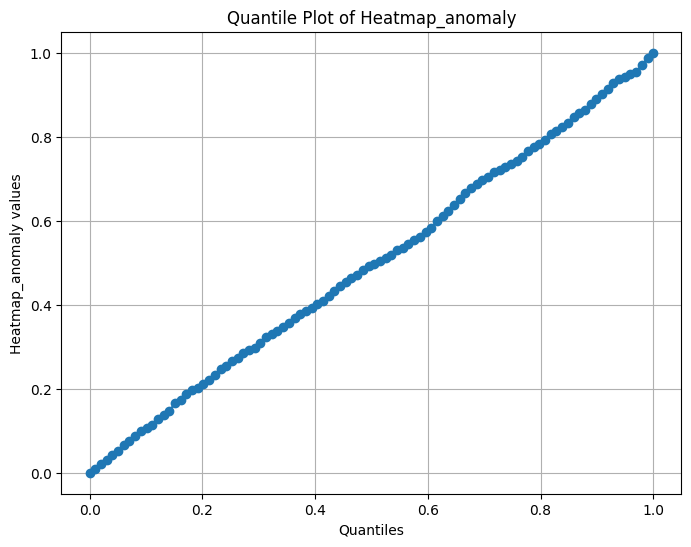

<Figure size 800x600 with 0 Axes>

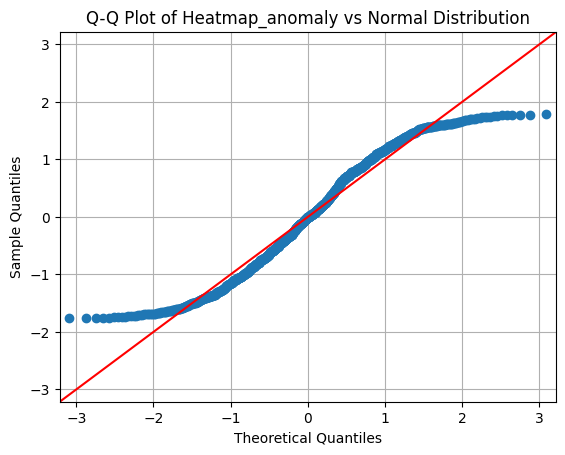

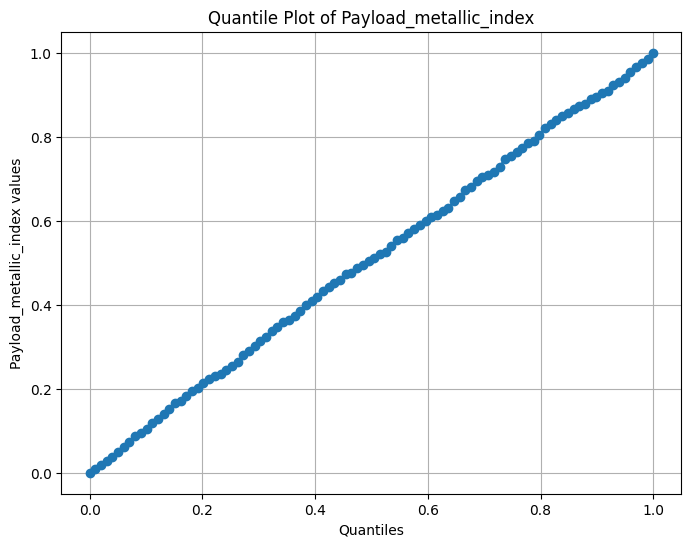

<Figure size 800x600 with 0 Axes>

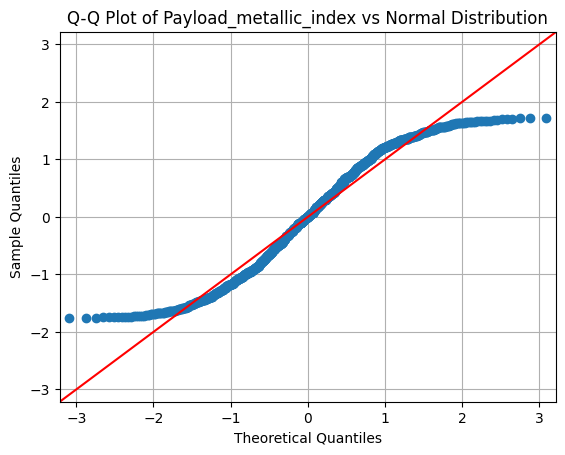

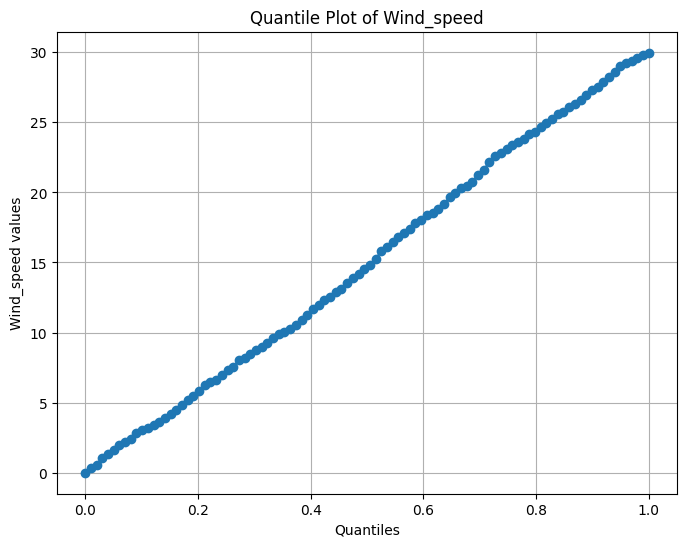

<Figure size 800x600 with 0 Axes>

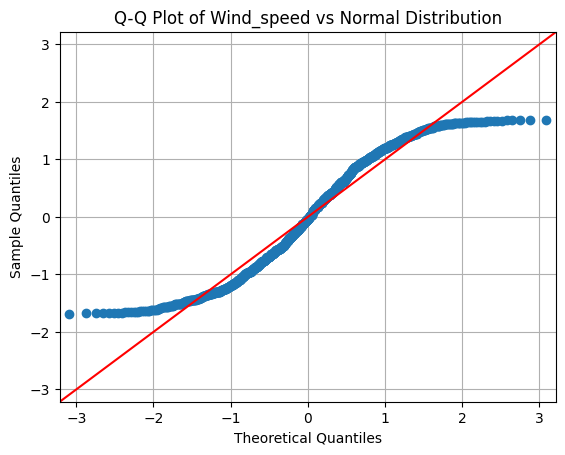

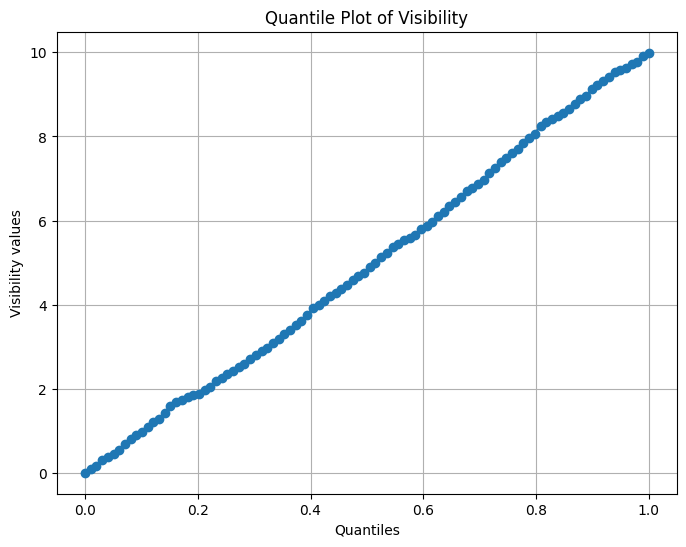

<Figure size 800x600 with 0 Axes>

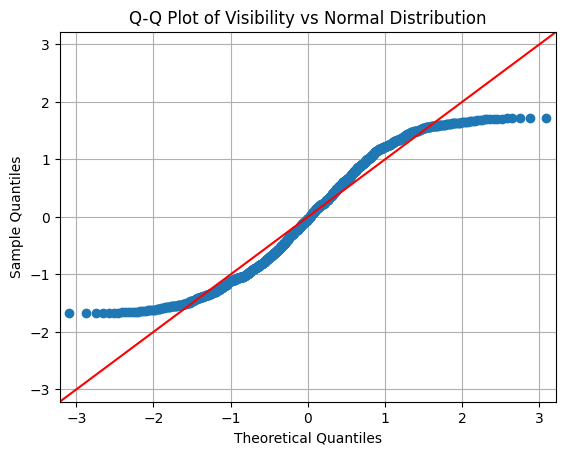

In [ ]:
# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# STEP 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# STEP 3: Load the dataset
file_path = "/content/drive/MyDrive/simulated_drone_dataset.csv"
df = pd.read_csv(file_path)

# STEP 4: Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("Numeric columns:", numeric_cols)

# STEP 5: Loop through all numeric features
for col in numeric_cols:
    data = df[col].dropna()

    # --- Quantile Plot ---
    plt.figure(figsize=(8,6))
    quantiles = np.linspace(0, 1, 100)
    values = np.quantile(data, quantiles)
    plt.plot(quantiles, values, marker="o")
    plt.title(f"Quantile Plot of {col}")
    plt.xlabel("Quantiles")
    plt.ylabel(f"{col} values")
    plt.grid(True)
    plt.show()

    # --- Q-Q Plot ---
    plt.figure(figsize=(8,6))
    sm.qqplot(data, line='45', fit=True)
    plt.title(f"Q-Q Plot of {col} vs Normal Distribution")
    plt.grid(True)
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import MinMaxScaler

# Load dataset
file_path = "simulated_drone_dataset.csv"
df = pd.read_csv(file_path)

# Correct feature selection (numeric only)
features = [
    "RCS", "Thermal_IR", "RF_power", "Metallic_index",
    "Altitude", "Speed", "Acceleration", "Turn_rate",
    "Payload_weight", "Heatmap_anomaly",
    "Payload_metallic_index", "Wind_speed", "Visibility"
]
num_df = df[features]

# Scale features for fair comparison
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(num_df)

# Distance Matrices
euclidean_matrix = squareform(pdist(data_scaled, metric='euclidean'))
manhattan_matrix = squareform(pdist(data_scaled, metric='cityblock'))
chebyshev_matrix = squareform(pdist(data_scaled, metric='chebyshev'))
minkowski_matrix = squareform(pdist(data_scaled, metric='minkowski', p=3))

# Preview results (5x5 block)
print("Euclidean (5x5):\n", euclidean_matrix[:5, :5])
print("\nManhattan (5x5):\n", manhattan_matrix[:5, :5])
print("\nChebyshev (5x5):\n", chebyshev_matrix[:5, :5])
print("\nMinkowski p=3 (5x5):\n", minkowski_matrix[:5, :5])

Euclidean (5x5):
 [[0.         1.48218077 1.65445555 1.32659786 1.51681107]
 [1.48218077 0.         1.81190845 1.31446524 1.24141464]
 [1.65445555 1.81190845 0.         1.6522155  1.78696888]
 [1.32659786 1.31446524 1.6522155  0.         1.10685396]
 [1.51681107 1.24141464 1.78696888 1.10685396 0.        ]]

Manhattan (5x5):
 [[0.         4.01414532 5.19789151 3.62631588 4.40341809]
 [4.01414532 0.         5.6274934  4.02623764 3.26690934]
 [5.19789151 5.6274934  0.         5.22552387 5.37144055]
 [3.62631588 4.02623764 5.22552387 0.         3.24942039]
 [4.40341809 3.26690934 5.37144055 3.24942039 0.        ]]

Chebyshev (5x5):
 [[0.         0.95953274 0.79350672 0.72894299 0.966633  ]
 [0.95953274 0.         0.93280023 0.65302218 0.79862037]
 [0.79350672 0.93280023 0.         0.83033063 0.93990048]
 [0.72894299 0.65302218 0.83033063 0.         0.53328954]
 [0.966633   0.79862037 0.93990048 0.53328954 0.        ]]

Minkowski p=3 (5x5):
 [[0.         1.14500958 1.18150822 0.99745909 1.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import pdist, squareform
from scipy.special import rel_entr

# ================================
# 1. Load Preprocessed Data
# ================================
file_path = "/content/simulated_drone_dataset.csv"
df = pd.read_csv(file_path)

# Select numeric features only
numeric_cols = df.select_dtypes(include=[np.number]).columns
data = df[numeric_cols].values

# ================================
# 2. Cosine Similarity
# ================================
cosine_sim_matrix = cosine_similarity(data)

print("Cosine Similarity (5x5 block):\n", cosine_sim_matrix[:5, :5])

# ================================
# 3. KL Divergence
# ================================
# KL requires probability distributions → normalize rows to sum=1
data_prob = data / data.sum(axis=1, keepdims=True)

# Compute KL divergence (row by row)
n = data_prob.shape[0]
kl_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        # KL(P||Q) = sum(P * log(P/Q))
        kl_matrix[i, j] = np.sum(rel_entr(data_prob[i], data_prob[j]))

print("\nKL Divergence (5x5 block):\n", kl_matrix[:5, :5])

Cosine Similarity (5x5 block):
 [[1.         0.99949531 0.99350736 0.88726316 0.86244622]
 [0.99949531 1.         0.99488233 0.89336944 0.86391909]
 [0.99350736 0.99488233 1.         0.92757366 0.89809115]
 [0.88726316 0.89336944 0.92757366 1.         0.93200987]
 [0.86244622 0.86391909 0.89809115 0.93200987 1.        ]]

KL Divergence (5x5 block):
 [[0.                inf 0.12752831 0.42356836        inf]
 [       inf        inf        inf        inf        inf]
 [0.18406809        inf 0.         0.22469958        inf]
 [0.83894391        inf 0.35253568 0.                inf]
 [       inf        inf        inf        inf        inf]]


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# ================================
# 1. Load dataset
# ================================
file_path = "/content/simulated_drone_dataset.csv"  # adjust if needed
df = pd.read_csv(file_path)

print("Initial shape:", df.shape)
print("Columns:\n", df.dtypes)

# ================================
# 2. Data Cleaning
# ================================

# Check missing values
print("\nMissing values per column:\n", df.isnull().sum())

# Fill numeric NaNs with mean, categorical with mode
for col in df.columns:
    if df[col].dtype in [np.float64, np.int64]:
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicates
df = df.drop_duplicates()

# ================================
# 3. Outlier Detection & Handling
# ================================
# Using IQR method
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Cap outliers (instead of removing)
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

# ================================
# 4. Data Transformation
# ================================
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Encode categorical variables
categorical_cols = df.select_dtypes(include=["object"]).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    # Show transformation mapping
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\nColumn: {col}")
    print("Mapping:", mapping)

# Scale numeric features
scaler = MinMaxScaler()   # or StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print("\nNumeric columns scaled using MinMaxScaler.")

# ================================
# 5. Data Reduction (optional)
# ================================
# Example: Drop irrelevant columns if any
df = df.drop(columns=["unnecessary_column"], errors="ignore")

print("\nFinal shape:", df.shape)
print(df.head())

Initial shape: (1000, 16)
Columns:
 RCS                           float64
Thermal_IR                    float64
RF_power                      float64
Metallic_index                float64
Altitude                      float64
Speed                         float64
Acceleration                  float64
Turn_rate                     float64
Payload_weight                float64
Heatmap_anomaly               float64
Payload_metallic_index        float64
Weather                        object
Wind_speed                    float64
GPS_zone                       object
Visibility                    float64
Recommended_countermeasure     object
dtype: object

Missing values per column:
 RCS                           0
Thermal_IR                    0
RF_power                      0
Metallic_index                0
Altitude                      0
Speed                         0
Acceleration                  0
Turn_rate                     0
Payload_weight                0
Heatmap_anomaly          


=== Naive Bayes ===
Confusion Matrix:
 [[ 10   0   0   0]
 [  3  16   4   0]
 [  0   3 101   4]
 [ 18   3  16  22]]
              precision    recall  f1-score   support

           0       0.32      1.00      0.49        10
           1       0.73      0.70      0.71        23
           2       0.83      0.94      0.88       108
           3       0.85      0.37      0.52        59

    accuracy                           0.74       200
   macro avg       0.68      0.75      0.65       200
weighted avg       0.80      0.74      0.74       200

✅ Test Accuracy: 0.745
✅ CV Accuracy: 0.721

=== Decision Tree ===
Confusion Matrix:
 [[ 10   0   0   0]
 [  1  15   5   2]
 [  0   1 107   0]
 [  0   1   0  58]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       0.88      0.65      0.75        23
           2       0.96      0.99      0.97       108
           3       0.97      0.98      0.97        59

    accuracy 

,Test Accuracy,CV Accuracy (10-fold),F1-Score,Recall,ROC-AUC
Naive Bayes,0.745,0.721,0.649665,0.750930,0.869741
Decision Tree,0.950,0.946,0.912475,0.906491,0.942609
SVM (RBF),0.860,0.855,0.777183,0.742269,0.959831


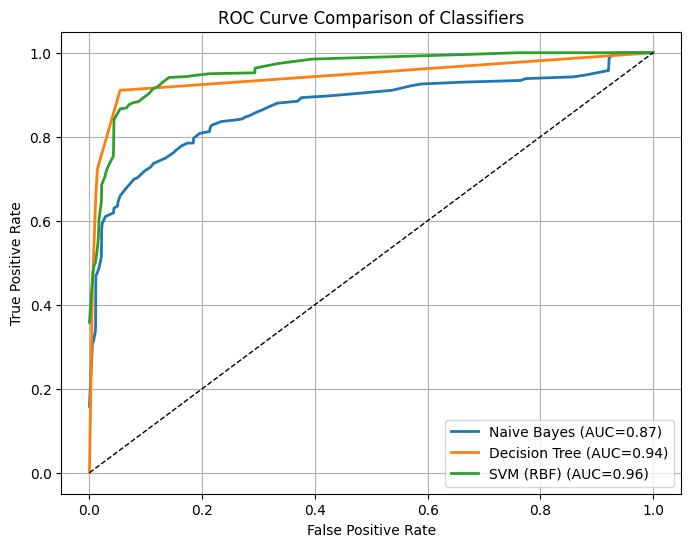


🏅 Best Model Based on F1-Score: Decision Tree
🏆 Best Model Based on ROC-AUC: SVM (RBF)

✅ Final Selected Best Model for Deployment: SVM (RBF)

📘 Selection Reasoning:
- F1-Score focuses on the model’s ability to balance precision and recall across classes.
- ROC-AUC captures how well the model separates all classes overall.
- The chosen model offers the best generalization and stability for multi-class drone countermeasure prediction.


In [ ]:
# ================================
# 📊 Classification, Evaluation & Best Model Selector (Enhanced)
# ================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, f1_score, recall_score
)
import matplotlib.pyplot as plt

# ==============================================
# 1️⃣ Load and Prepare Data
# ==============================================
# Example: df = pd.read_csv("your_dataset.csv")

target_col = df.columns[-1]   # last column as target
X = df.drop(columns=[target_col])
y = df[target_col]

# Train-test split (80–20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================================
# 2️⃣ Define Models
# ==============================================
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42)
}

# ==============================================
# 3️⃣ Train, Evaluate & Collect Results
# ==============================================
results = {}
roc_data = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # Metrics
    acc = model.score(X_test, y_test)
    cv_score = cross_val_score(model, X, y, cv=10).mean()
    f1 = f1_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")

    # Display confusion matrix and report
    print(f"\n=== {name} ===")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(f"✅ Test Accuracy: {acc:.3f}")
    print(f"✅ CV Accuracy: {cv_score:.3f}")

    # Store metrics
    results[name] = {
        "Test Accuracy": acc,
        "CV Accuracy (10-fold)": cv_score,
        "F1-Score": f1,
        "Recall": recall
    }

    # --- ROC-AUC Calculation (Multi-class One-vs-Rest) ---
    y_test_bin = label_binarize(y_test, classes=np.unique(y))
    n_classes = y_test_bin.shape[1]
    fpr, tpr, roc_auc = {}, {}, {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    # Save ROC info
    roc_data[name] = (all_fpr, mean_tpr, macro_auc)

# ==============================================
# 4️⃣ Summary Table
# ==============================================
results_df = pd.DataFrame(results).T
results_df["ROC-AUC"] = [roc_data[m][2] for m in roc_data]
print("\n📋 Performance Summary:")
display(results_df)

# ==============================================
# 5️⃣ ROC Curve Plot (Multi-class Comparison)
# ==============================================
plt.figure(figsize=(8,6))
for name, (fpr, tpr, auc_val) in roc_data.items():
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("ROC Curve Comparison of Classifiers")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# ==============================================
# 6️⃣ Best Model Selection (F1 & ROC-AUC)
# ==============================================
best_f1_model = results_df["F1-Score"].idxmax()
best_auc_model = results_df["ROC-AUC"].idxmax()

print(f"\n🏅 Best Model Based on F1-Score: {best_f1_model}")
print(f"🏆 Best Model Based on ROC-AUC: {best_auc_model}")

# Final model choice logic
if best_f1_model == best_auc_model:
    best_model_name = best_f1_model
else:
    # Prefer ROC-AUC if it indicates stronger class separation
    best_model_name = best_auc_model

best_model_instance = models[best_model_name]
print(f"\n✅ Final Selected Best Model for Deployment: {best_model_name}")

# Reasoning
print("\n📘 Selection Reasoning:")
print("- F1-Score focuses on the model’s ability to balance precision and recall across classes.")
print("- ROC-AUC captures how well the model separates all classes overall.")
print("- The chosen model offers the best generalization and stability for multi-class drone countermeasure prediction.")
